<a href="https://colab.research.google.com/github/BruBurian/FarmTech-na-Era-da-Cloud-Computing-/blob/main/BrunoBurian_rm568025_pbl_fase5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Importação

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#2. Carregar dados

In [ ]:
df = pd.read_csv('crop_yield.csv')

df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


#3. Análise exploratória

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


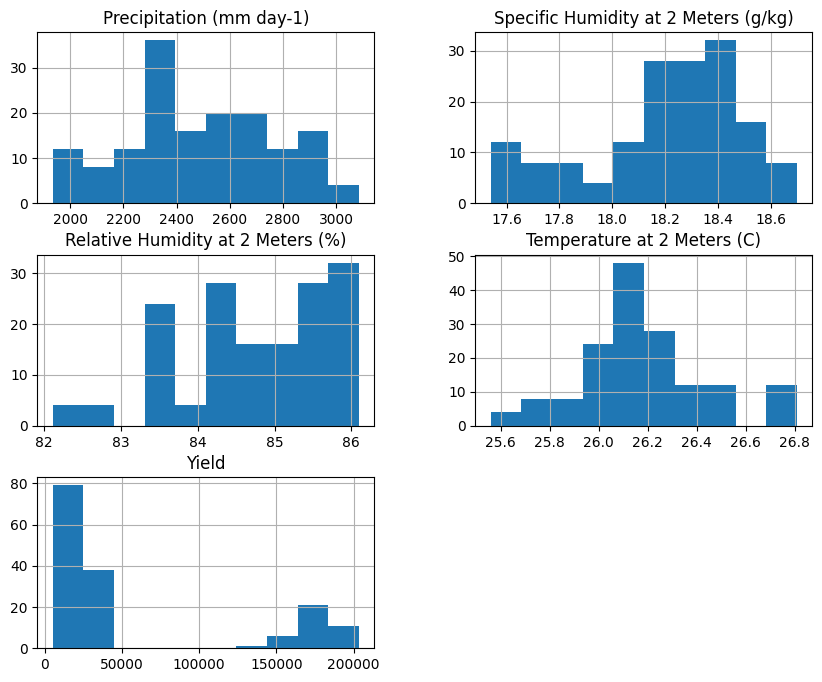

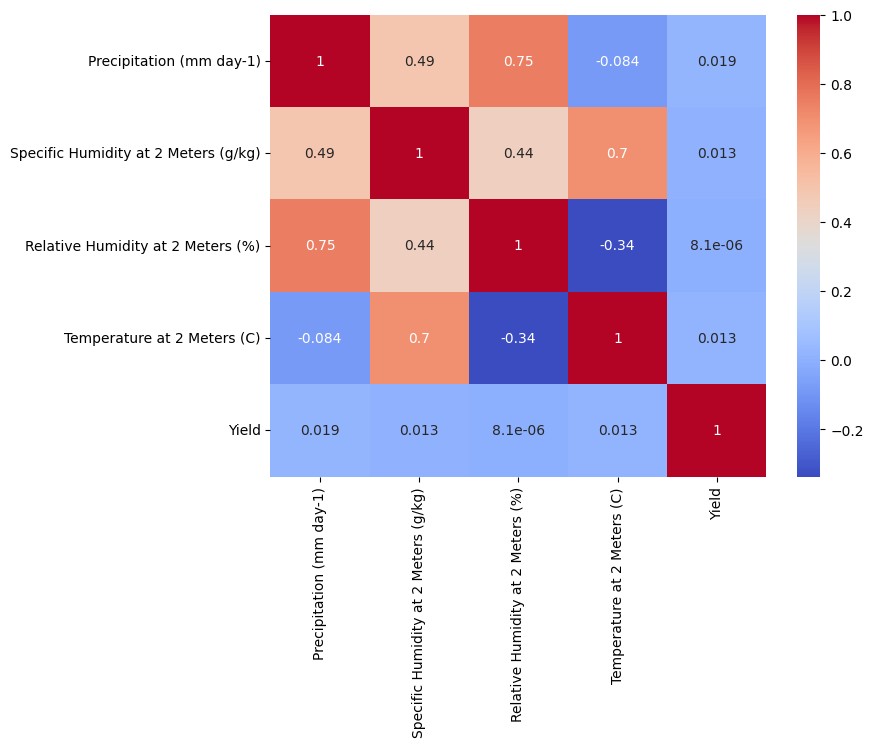

In [ ]:
df.info()
df.describe()

# valores nulos
df.isnull().sum()

# histogramas
df.hist(figsize=(10,8))
plt.show()

# correlação
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

#4. Pré-processamento

In [ ]:
le = LabelEncoder()
df['Crop'] = le.fit_transform(df['Crop'])

# separação
X = df.drop('Yield', axis=1)
y = df['Yield']

# divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# normalização (importante para alguns modelos)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#5. Clusterização

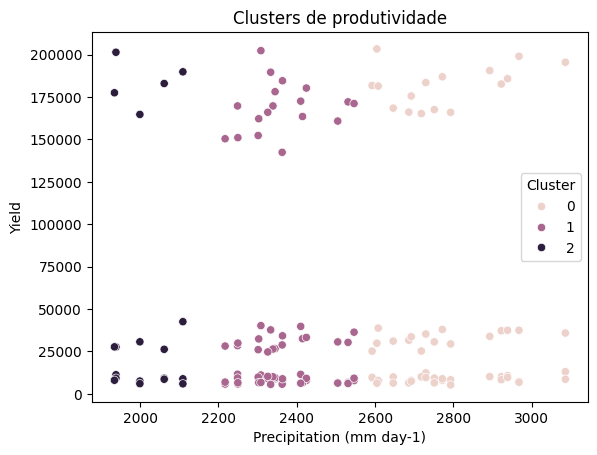

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

sns.scatterplot(x=df.iloc[:,1], y=df['Yield'], hue=df['Cluster'])
plt.title('Clusters de produtividade')
plt.show()

#6. Modelos

In [ ]:
def avaliar_modelo(nome, modelo):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f'\nModelo: {nome}')
    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R2: {r2:.2f}')

In [ ]:
#Rodando os 5 modelos
avaliar_modelo("Linear Regression", LinearRegression())
avaliar_modelo("Decision Tree", DecisionTreeRegressor())
avaliar_modelo("Random Forest", RandomForestRegressor())
avaliar_modelo("KNN", KNeighborsRegressor())
avaliar_modelo("SVR", SVR())


Modelo: Linear Regression
MAE: 53724.49
RMSE: 65364.57
R2: -0.10

Modelo: Decision Tree
MAE: 2958.03
RMSE: 4871.52
R2: 0.99

Modelo: Random Forest
MAE: 2745.03
RMSE: 4954.67
R2: 0.99

Modelo: KNN
MAE: 28503.97
RMSE: 35675.87
R2: 0.67

Modelo: SVR
MAE: 38973.19
RMSE: 71312.76
R2: -0.31
